### モジュールのインポート

In [1]:
from yikit.feature_selection import FilterSelector
from sklearn.datasets import load_diabetes
import seaborn as sns
import pandas as pd

### サンプルデータの取得

In [2]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes["data"], columns=diabetes["feature_names"])
y = pd.Series(diabetes["target"])
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### 特徴量同士の相関をみてみる

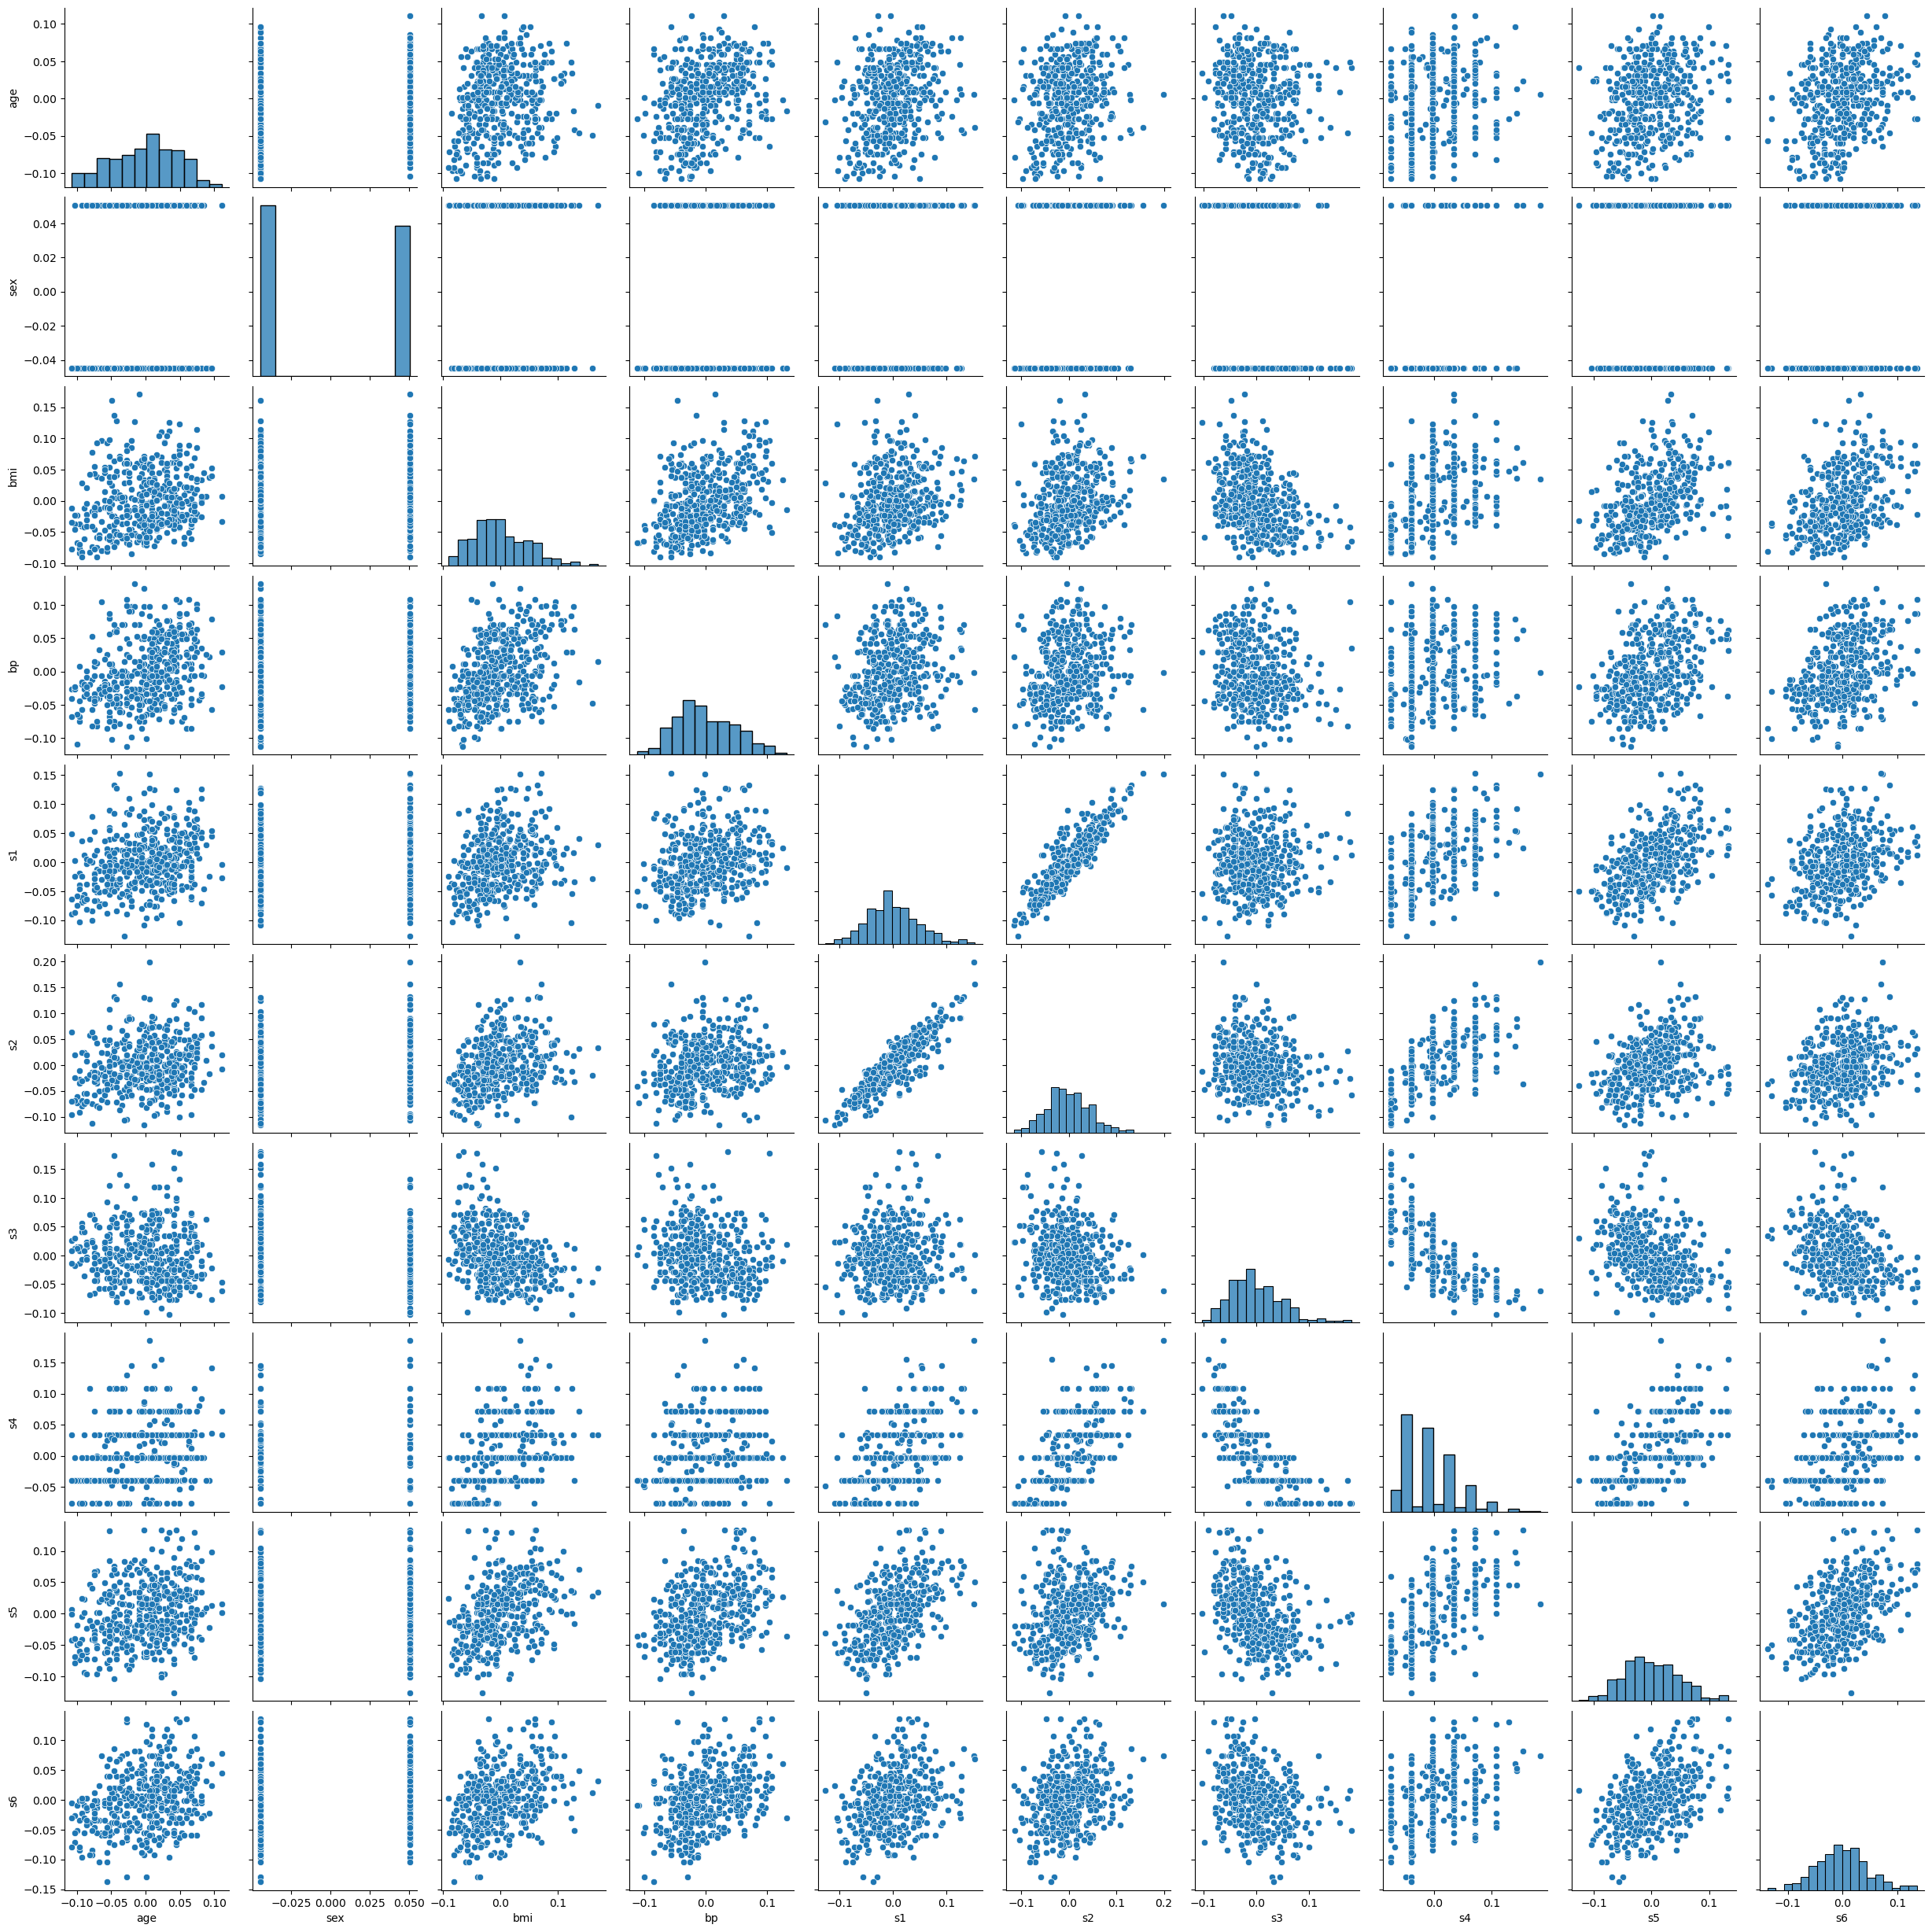

In [3]:
sns.pairplot(X)

### 削減してみる

In [4]:
selector = FilterSelector(r=0.85, n_jobs=-1)
selector.fit(X)
X_selected = X.loc[:, selector.get_support()]
X_selected.head()

computing p-values:   0%|          | 0/1 [00:00<?, ?it/s]

[(4, 5, 8.341806776825279e-158)]


,age,sex,bmi,bp,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### 削減されたペアを表示

In [5]:
for i in range(selector.corr_.shape[0]):
    for j in range(i, selector.corr_.shape[1]):
        if 1 > selector.corr_[i][j][0] > 0.9:
            print(selector.corr_[i][j], X.columns[i], X.columns[j])

### 相関係数

In [6]:
pd.DataFrame(selector.corr_[:, :, 0], columns=X.columns, index=X.columns)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


### p値

In [7]:
pd.DataFrame(selector.corr_[:, :, 1], columns=X.columns, index=X.columns)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,0.0,1.0,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,1.0
sex,1.0,0.0,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,1.0
bmi,1.0,1.0,0.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,1.0
bp,1.0,1.0,1.0,0.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,1.0
s1,1.0,1.0,1.0,1.0,0.000000e+00,8.341807e-158,1.0,1.0,1.0,1.0
s2,1.0,1.0,1.0,1.0,8.341807e-158,0.000000e+00,1.0,1.0,1.0,1.0
s3,1.0,1.0,1.0,1.0,1.000000e+00,1.000000e+00,0.0,1.0,1.0,1.0
s4,1.0,1.0,1.0,1.0,1.000000e+00,1.000000e+00,1.0,0.0,1.0,1.0
s5,1.0,1.0,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,0.0,1.0
s6,1.0,1.0,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,0.0
